In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
!pip install tflite-support

2026-02-26 11:20:58.824715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772104859.221667      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772104859.332386      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772104860.305914      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772104860.305959      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772104860.305962      24 computation_placer.cc:177] computation placer alr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.3/390.3 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for tflite-support: filename=tflite_support-0.1.0a1-cp312-cp312-linux_x86_64.whl size=6042493 sha256=cabbbf0e273dc8b8b40f642ede7aa697131f76f2eb9fecd2ff5c765cccc090b6
  Stored in directory: /root/.cache/pip/wheels/5d/6f/bc/8b85ad0e51d3c8f82c590b321f2c5b35c41fbe84ad93271397
Successfully built tflite-support


In [2]:
INPUT_DIR = "/kaggle/input/house-plant-species/house_plant_species"
WORK_DIR = "/kaggle/working/house_plant_species"

def clean_and_prepare_data(source_dir, target_dir):
    # 1. Copy data if it doesn't exist in working directory
    if not os.path.exists(target_dir):
        shutil.copytree(source_dir, target_dir)
    else:
        print(f"Data already exists at {target_dir}, skipping copy.")

    # 2. Scan and remove corrupt images from the writable directory
    removed_count = 0
    
    for root, dirs, files in os.walk(target_dir):
        for file in files:
            file_path = os.path.join(root, file)
            # Check image extensions
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                try:
                    # Try to decode to check for corruption
                    img_bytes = tf.io.read_file(file_path)
                    tf.io.decode_image(img_bytes)
                except (tf.errors.InvalidArgumentError, ValueError):
                    # If decoding fails, delete the file
                    os.remove(file_path)
                    removed_count += 1
    
    print(f"\nTotal corrupt files removed: {removed_count}")
    return target_dir

# Execute the cleaning function and get the new dataset path
DATASET_PATH = clean_and_prepare_data(INPUT_DIR, WORK_DIR)

I0000 00:00:1772105170.491248      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772105170.497072      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Total corrupt files removed: 89


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = temp_ds.take(len(temp_ds)//2)
test_ds = temp_ds.skip(len(temp_ds)//2)


Found 14535 files belonging to 47 classes.
Using 11628 files for training.
Found 14535 files belonging to 47 classes.
Using 2907 files for validation.


In [4]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

train_ds = train_ds.map(lambda x, y: (x, y))
val_ds   = val_ds.map(lambda x, y: (x, y))


In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)  
])


In [7]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model initially
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) 
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)



In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.2
    )
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10


E0000 00:00:1772105439.940124      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772105529.266253     120 cuda_dnn.cc:529] Loaded cuDNN version 91002


364/364 ━━━━━━━━━━━━━━━━━━━━ 139s 105ms/step - accuracy: 0.3147 - loss: 2.7576 - val_accuracy: 0.6535 - val_loss: 1.4048 - learning_rate: 0.0010
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.6489 - loss: 1.3678 - val_accuracy: 0.7021 - val_loss: 1.1300 - learning_rate: 0.0010
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.7091 - loss: 1.1001 - val_accuracy: 0.7174 - val_loss: 1.0266 - learning_rate: 0.0010
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.7407 - loss: 0.9665 - val_accuracy: 0.7458 - val_loss: 0.9333 - learning_rate: 0.0010
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.7579 - loss: 0.8911 - val_accuracy: 0.7472 - val_loss: 0.8971 - learning_rate: 0.0010
Epoch 6/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.7705 - loss: 0.8240 - val_accuracy: 0.7549 - val_loss: 0.8628 - learning_rate: 0.0010
Epoch 7/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.7781 - loss: 0.78

In [11]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [12]:
base_model.trainable = True

for layer in base_model.layers[-60:]:
    layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20


E0000 00:00:1772105847.914643      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


364/364 ━━━━━━━━━━━━━━━━━━━━ 84s 163ms/step - accuracy: 0.6779 - loss: 1.1460 - val_accuracy: 0.8403 - val_loss: 0.5876 - learning_rate: 1.0000e-04
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 56s 155ms/step - accuracy: 0.8688 - loss: 0.4452 - val_accuracy: 0.8674 - val_loss: 0.5036 - learning_rate: 1.0000e-04
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.9190 - loss: 0.2840 - val_accuracy: 0.8729 - val_loss: 0.4805 - learning_rate: 1.0000e-04
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - accuracy: 0.9408 - loss: 0.2002 - val_accuracy: 0.8806 - val_loss: 0.4425 - learning_rate: 1.0000e-04
Epoch 5/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 156ms/step - accuracy: 0.9637 - loss: 0.1378 - val_accuracy: 0.8903 - val_loss: 0.4319 - learning_rate: 1.0000e-04
Epoch 6/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 56s 155ms/step - accuracy: 0.9709 - loss: 0.1079 - val_accuracy: 0.8896 - val_loss: 0.4347 - learning_rate: 1.0000e-04
Epoch 7/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 155ms/step - 

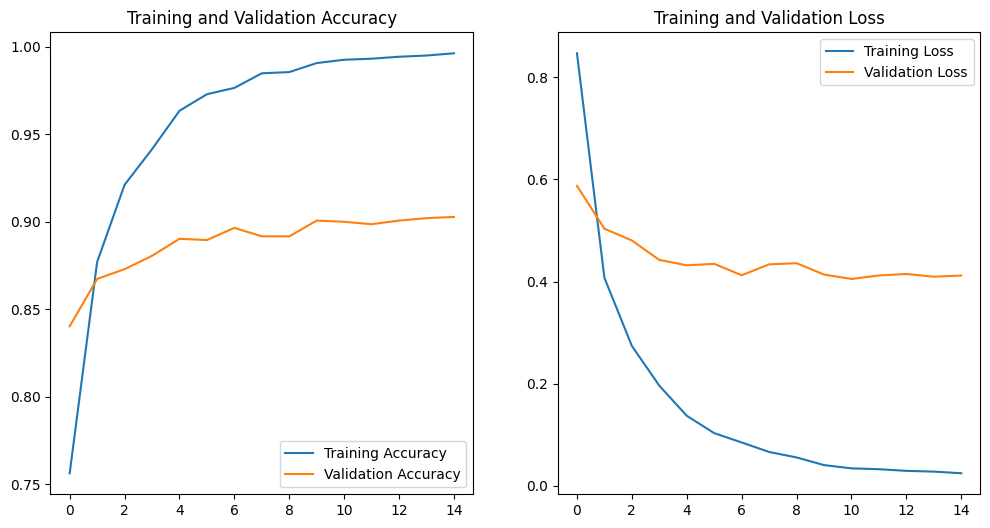


--- Final Test Set Evaluation ---
Test Accuracy: 90.87%
Test Loss: 0.3274

Generating predictions for Confusion Matrix (this may take a moment)...

--- Classification Report ---
                                            precision    recall  f1-score   support

     African Violet (Saintpaulia ionantha)       0.94      1.00      0.97        31
                                 Aloe Vera       0.95      0.95      0.95        20
          Anthurium (Anthurium andraeanum)       0.92      0.96      0.94        48
             Areca Palm (Dypsis lutescens)       0.82      1.00      0.90        18
       Asparagus Fern (Asparagus setaceus)       1.00      0.93      0.97        15
                    Begonia (Begonia spp.)       0.79      0.73      0.76        15
     Bird of Paradise (Strelitzia reginae)       1.00      0.95      0.97        20
         Birds Nest Fern (Asplenium nidus)       1.00      0.76      0.87        34
        Boston Fern (Nephrolepis exaltata)       0.95      0.95 

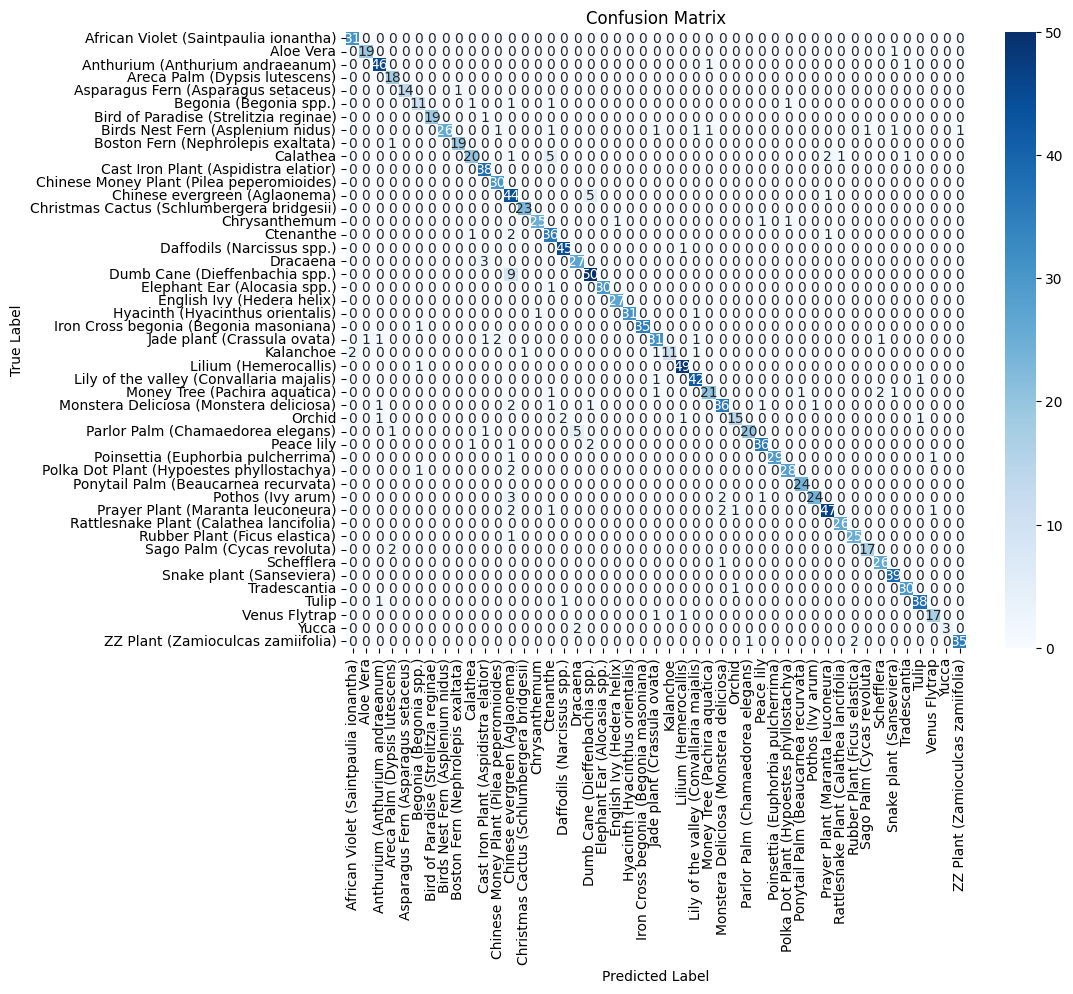

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']
loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# --- 2. EVALUATE ON TEST SET ---
# Get the absolute final numbers on unseen data
print("\n--- Final Test Set Evaluation ---")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


y_true = []
y_pred = []

print("\nGenerating predictions for Confusion Matrix (this may take a moment)...")
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Detailed Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Heatmap Visualization
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
import os

dataset_path = "/kaggle/input/house-plant-species/house_plant_species"   # ⚠️ change this

class_names = sorted(os.listdir(dataset_path))

print(class_names)

['African Violet (Saintpaulia ionantha)', 'Aloe Vera', 'Anthurium (Anthurium andraeanum)', 'Areca Palm (Dypsis lutescens)', 'Asparagus Fern (Asparagus setaceus)', 'Begonia (Begonia spp.)', 'Bird of Paradise (Strelitzia reginae)', 'Birds Nest Fern (Asplenium nidus)', 'Boston Fern (Nephrolepis exaltata)', 'Calathea', 'Cast Iron Plant (Aspidistra elatior)', 'Chinese Money Plant (Pilea peperomioides)', 'Chinese evergreen (Aglaonema)', 'Christmas Cactus (Schlumbergera bridgesii)', 'Chrysanthemum', 'Ctenanthe', 'Daffodils (Narcissus spp.)', 'Dracaena', 'Dumb Cane (Dieffenbachia spp.)', 'Elephant Ear (Alocasia spp.)', 'English Ivy (Hedera helix)', 'Hyacinth (Hyacinthus orientalis)', 'Iron Cross begonia (Begonia masoniana)', 'Jade plant (Crassula ovata)', 'Kalanchoe', 'Lilium (Hemerocallis)', 'Lily of the valley (Convallaria majalis)', 'Money Tree (Pachira aquatica)', 'Monstera Deliciosa (Monstera deliciosa)', 'Orchid', 'Parlor Palm (Chamaedorea elegans)', 'Peace lily', 'Poinsettia (Euphorbia 

In [15]:
with open("labels.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("labels.txt created successfully")

labels.txt created successfully


In [16]:
!pip uninstall -y tflite-support
!pip install tflite-support==0.4.4

Found existing installation: tflite-support 0.1.0a1
Uninstalling tflite-support-0.1.0a1:
  Successfully uninstalled tflite-support-0.1.0a1
ERROR: Could not find a version that satisfies the requirement tflite-support==0.4.4 (from versions: 0.1.0a0.dev3, 0.1.0a0.dev4, 0.1.0a0.dev5, 0.1.0a0, 0.1.0a1)
ERROR: No matching distribution found for tflite-support==0.4.4


In [17]:
model.save('plant_model_finetuned.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

with open('plant_model_quantized.tflite', 'wb') as f:
    f.write(tflite_quant_model)

INFO:tensorflow:Assets written to: /tmp/tmpixpp4xao/assets


INFO:tensorflow:Assets written to: /tmp/tmpixpp4xao/assets


Saved artifact at '/tmp/tmpixpp4xao'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 47), dtype=tf.float32, name=None)
Captures:
  132174790541584: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132174790541968: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132176062261264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059533648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059533456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059533264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059531920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059532112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059535376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176059535568: TensorSpec(shape=(), dtype=tf.resource, name

W0000 00:00:1772106761.353122      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772106761.353170      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772106761.561330      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
